下载 Hugging Face 上 OpenAI 提供的 GPT2 模型参数。先导入 Hugging Face 的 transformers 包。

In [1]:
from transformers import GPT2LMHeadModel

d:\ProgramData\Miniconda3\envs\d2l\lib\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.5)
  from scipy.sparse import csr_matrix, issparse


提取模型中的张量参数，并打印形状。

In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()   # extract tensors as dict

for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

训练好模型后的可视化代码。要求在同目录 log 文件夹下 log.txt 中保存有日志文件。

Min Train Loss: 2.894243
Min Validation Loss: 3.816319
Max Hellaswag eval: 0.3105


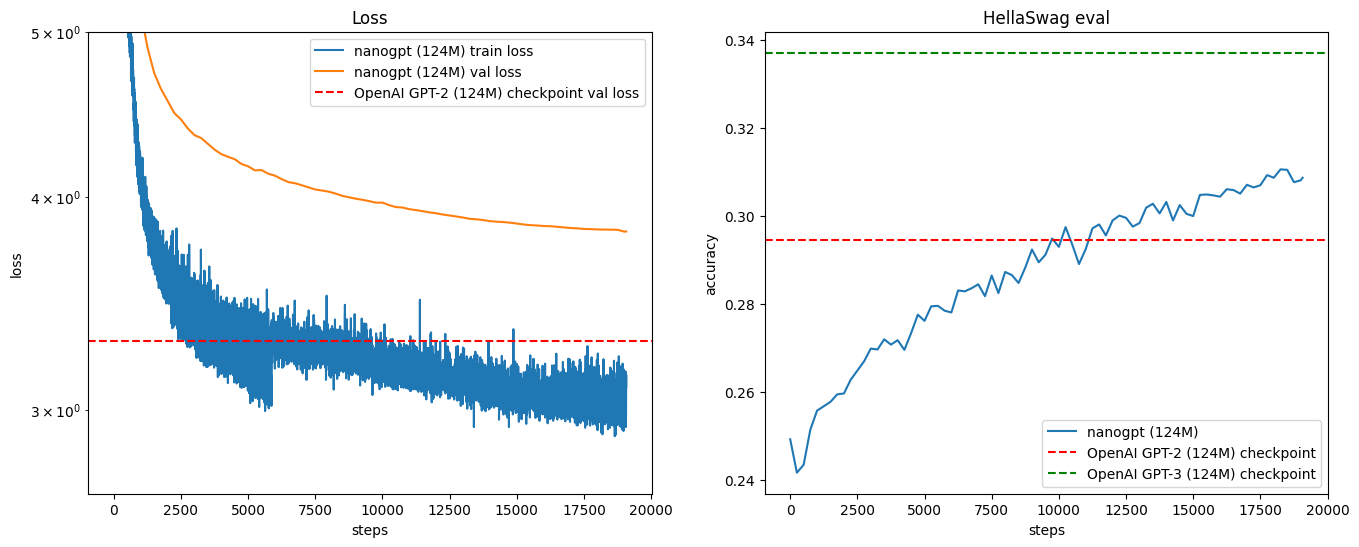

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 模型规模大小
sz = "124M"

# 基线模型的损失、hella 评估成绩
loss_baseline = {
    # GPT2 在本项目使用的验证集的成绩
    # 对 GPT2 来说不太公平，但可以作为一个很好的参考
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# 区分出日志文件中的三种成绩：train loss, valid loss, hellaswag acc
streams = {}    # 初始化存储字典
# 从 log/log.txt 读取
with open('log/log.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()
        if not parts:
            continue    # 跳过空行

        step = int(parts[0])

        # 后面每两个字段是一组：stream, value
        for i in range(1, len(parts), 2):
            stream = parts[i]
            val = float(parts[i + 1])
            # 第一次遇见某种成绩时，初始化字典
            if stream not in streams:
                streams[stream] = {}
            # 根据 step 写入键值对
            streams[stream][step] = val

# 类型转换，将 streams 中的 {step: val} 转成 (steps[], vals[])
streams_xy = {}
for k, v in streams.items():
    # v 是字典，把字典取元素，迭代器转成 list 并排序
    """
    例如 v 的内容为 {step1: val1, step2: val2, ...}
    v.items() 迭代器返回 (step1, val1), ...
    list 转为 [(step1, val1), ...]
    sorted 按照 step 的顺序排序
    """
    xy = sorted(list(v.items()))
    """
    zip(*xy) 得到 ((step1, step2, ...), (val1, val2, ...))
    list 转为 [(step1, step2, ...), (val1, val2, ...)]
    """
    streams_xy[k] = list(zip(*xy))

# 设置图片大小
plt.figure(figsize=(16, 6))

# Panel 1: 损失函数可视化，同时展示训练集和验证集
plt.subplot(121)
xs, ys = streams_xy["train"]
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"]
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# 绘制 GPT-2 基线
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=5.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag 评估正确率
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag 评估 acc
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# 绘制 GPT 基线
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))